In [1]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [46]:
data_path = "/home/riccardo/Documents/orbit/source/standalone/logs/rsl_rl/unitree_go1_jump/"

In [77]:
# results = data_path +"_test.bin"
results = data_path +"test.bin"

In [78]:
data = joblib.load(results)

In [79]:
data

array([[[ 1.43096924e-01,  2.03186035e-01,  4.00000036e-01],
        [ 2.44171143e-01, -8.93554688e-02,  4.00000036e-01],
        [ 5.20645142e-01, -1.68334961e-01,  4.00000036e-01],
        ...,
        [ 6.68441772e-01,  2.00668335e-01,  4.00000036e-01],
        [ 1.60781860e-01, -4.62341309e-02,  4.00000036e-01],
        [ 8.47824097e-01, -6.69860840e-02,  4.00000036e-01]],

       [[-2.75584015e+02,  4.18712311e+01,  3.99994045e-01],
        [-6.85780792e+01,  2.48869049e+02,  3.99992228e-01],
        [-7.45758133e+01,  1.78772430e+01,  3.99991959e-01],
        ...,
        [ 1.26306076e+02, -1.61932709e+02,  3.99993896e-01],
        [ 1.14274475e+02, -2.99334259e+01,  3.99993390e-01],
        [ 1.52691345e+01, -5.84826660e+00,  4.32276934e-01]]],
      dtype=float32)

In [80]:
data.shape

(2, 10000, 3)

In [81]:
des = data[0][:,:2]
des

array([[ 0.14309692,  0.20318604],
       [ 0.24417114, -0.08935547],
       [ 0.52064514, -0.16833496],
       ...,
       [ 0.6684418 ,  0.20066833],
       [ 0.16078186, -0.04623413],
       [ 0.8478241 , -0.06698608]], dtype=float32)

In [82]:
actual = data[1][:,:2]
actual

array([[-275.584    ,   41.87123  ],
       [ -68.57808  ,  248.86905  ],
       [ -74.57581  ,   17.877243 ],
       ...,
       [ 126.306076 , -161.93271  ],
       [ 114.274475 ,  -29.933426 ],
       [  15.2691345,   -5.8482666]], dtype=float32)

In [55]:
err = np.linalg.norm(data[0][:,:2] - data[1][:,:2], axis=1)
err

array([0.03987739, 0.04025737, 0.02022043, ..., 0.02227478, 0.0254719 ,
       0.12955776], dtype=float32)

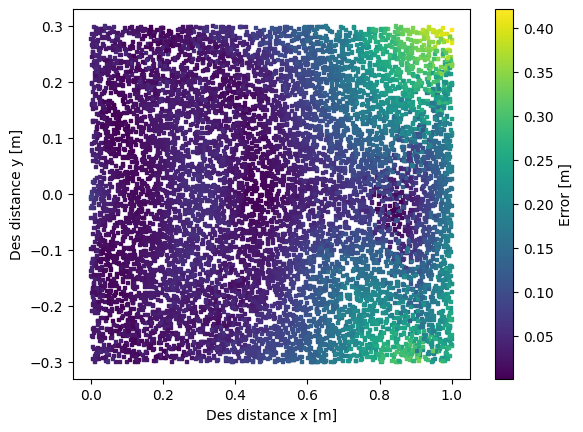

In [66]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=err)
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err.pdf")
plt.show()

In [36]:
#  try to interpolate data
grid_x, grid_y = np.mgrid[des[:,0].min():des[:,0].max():100j, des[:,1].min():des[:,1].max():100j]

In [37]:
from scipy.ndimage import gaussian_filter

In [42]:
grid_z = griddata(des, err, (grid_x, grid_y), method='linear')
# grid_z = gaussian_filter(grid_z, sigma=1)

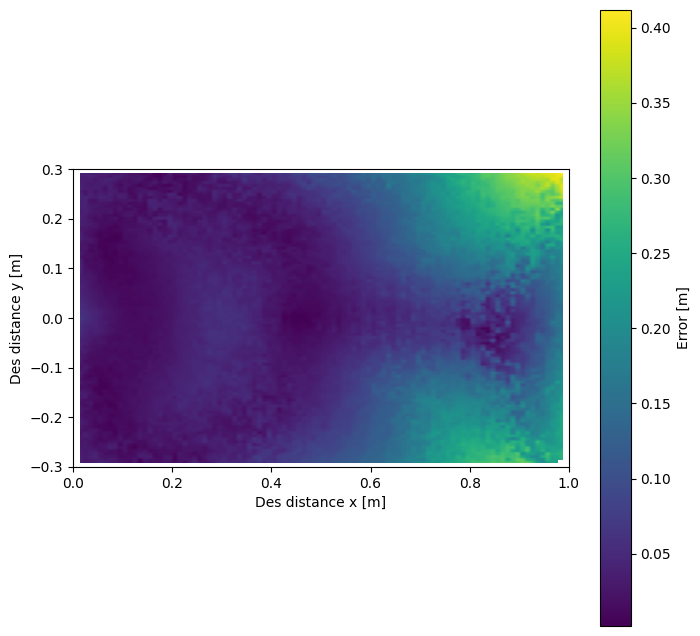

In [64]:
plt.figure(figsize=(8, 8))
plt.imshow(grid_z.T, extent=(0,1,-.3,.3), origin='lower')
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err_interpolated.pdf")
plt.show()

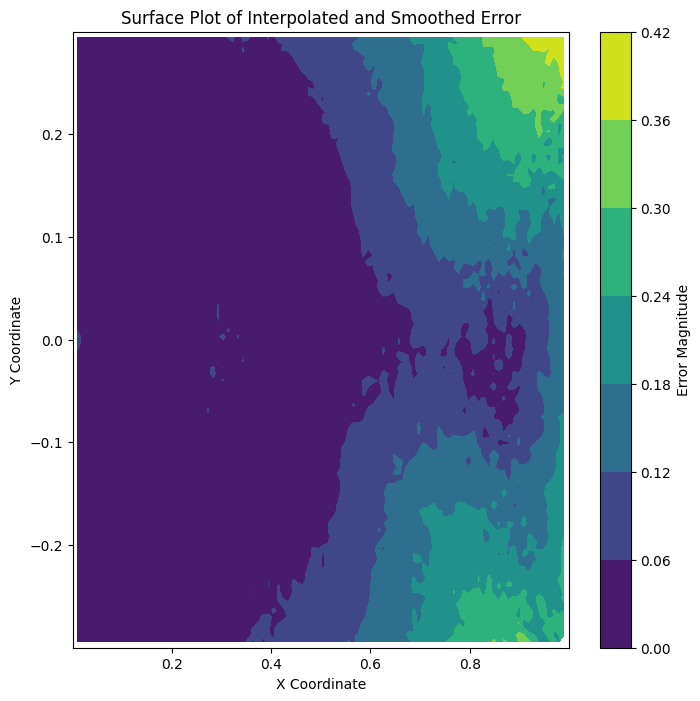

In [44]:
plt.figure(figsize=(8, 8))
plt.contourf(grid_x, grid_y, grid_z, cmap='viridis')
plt.colorbar(label='Error Magnitude')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Surface Plot of Interpolated and Smoothed Error')
plt.show()

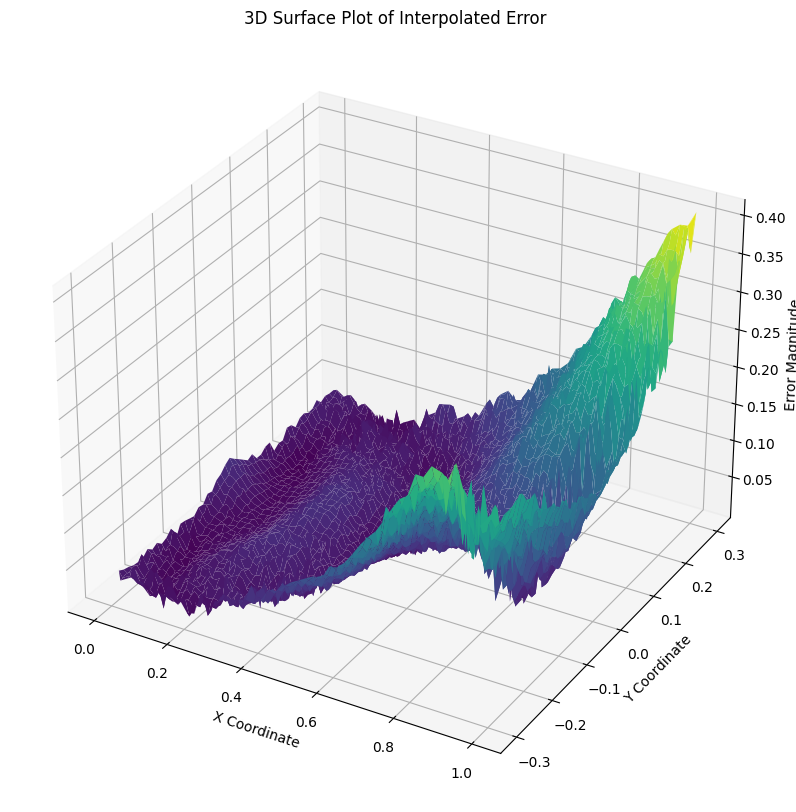

In [45]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(grid_x, grid_y, grid_z, cmap='viridis')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Error Magnitude')
ax.set_title('3D Surface Plot of Interpolated Error')
plt.show()


In [28]:
des_dist = np.linalg.norm(des, axis=1)
des_dist

array([0.36727893, 0.52740496, 0.22251116, ..., 0.4266518 , 0.8646792 ,
       0.7900778 ], dtype=float32)

In [29]:
actual_dist = np.linalg.norm(actual, axis=1)
actual_dist

array([0.40714753, 0.49588722, 0.21928874, ..., 0.43070275, 0.84830433,
       0.66552657], dtype=float32)

In [32]:
np.linalg.norm([0.6,.3])

0.6708203932499369

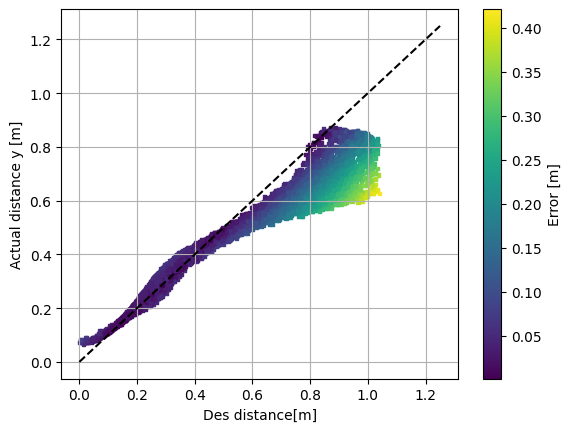

In [67]:
plt.grid()
plt.scatter(des_dist,actual_dist, np.full(des[: , 1].shape,5), marker='s', c=err, alpha=1)
plt.plot([0.0,1.25],[0.0,1.25], '--', color="black")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance[m]")
plt.ylabel("Actual distance y [m]")
plt.savefig(data_path+"diag_err.pdf")
plt.show()

In [70]:
perc_err = err / des_dist
perc_err

array([0.10857522, 0.07633104, 0.0908738 , ..., 0.05220833, 0.0294582 ,
       0.163981  ], dtype=float32)

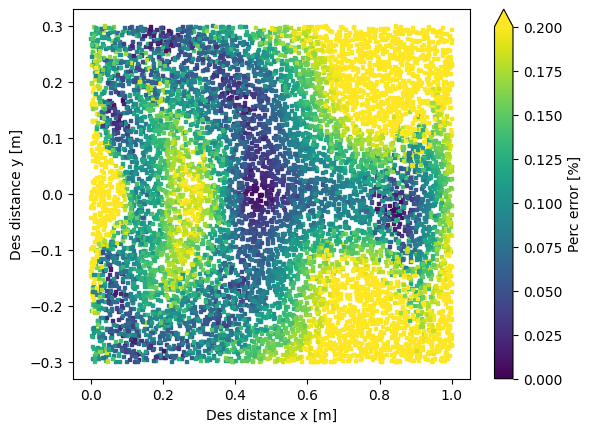

In [76]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=perc_err, vmin=0, vmax=.2)
plt.colorbar(label="Perc error [%]", extend='max')
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"perc_err.pdf")
plt.show()